In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import seaborn as sns
from folktables import ACSDataSource, ACSEmployment, ACSIncome
from sklearn.linear_model import LogisticRegression
import folktables

In [96]:
def correlation_with_label(df: pd.DataFrame, label_col: str, method: str = "pearson"):
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found in dataframe")

    # Keep only numeric columns
    numeric_df = df.select_dtypes(include="number")

    if label_col not in numeric_df.columns:
        raise ValueError("Label column must be numeric to compute correlation")

    corrs = numeric_df.corr(method=method)[label_col]

    # Drop self-correlation and sort
    corrs = corrs.drop(label_col).sort_values(key=abs, ascending=False)

    return corrs


In [94]:
ACSEmployment = folktables.BasicProblem(
    features=[
        'SCHL',
        'MAR',
        'RELP',
        'DIS',
        'ESP',
        'CIT',
        'MIG',
        'MIL',
        'ANC',
        'NATIVITY',
        'DEAR',
        'DEYE',
        'DREM',
        'SEX',
        'RAC1P',
    ],
    target='ESR',
    target_transform=lambda x: (x == 1).astype(int),
    #group='RAC1P',
    preprocess=lambda x: x,
    postprocess=lambda x: np.nan_to_num(x, -1),
)

In [104]:
ACSIncome = folktables.BasicProblem(
    features=[
        'COW',
        'SCHL',
        'MAR',
        'OCCP',
        'POBP',
        'RELP',
        #'WKHP',
        'SEX',
        'RAC1P',
        'AGEP',
    ],
    target='PINCP',
    target_transform=lambda x: (x > 30000).astype(int), #.replace({0: -1}),
    preprocess=folktables.adult_filter,
    postprocess=lambda x: x,  
)

In [109]:
task = ACSEmployment
weight_col = 'WKHP'
#------------------------
# Load data
#------------------------


data_source = ACSDataSource(
    survey_year='2018',
    horizon='1-Year',
    survey='person'
)

state = ["AL"]
acs_data = data_source.get_data(states=state, download=True)
filtered_data = folktables.adult_filter(acs_data).reset_index(drop=True)

# ---- Extract full labels ONCE to inspect ratios
_, y_full, _ = task.df_to_numpy(filtered_data)

# ---- Print label ratios BEFORE sampling
n_pos = np.sum(y_full == 1)
n_neg = np.sum(y_full == 0)

print("Label distribution BEFORE sampling:")
print(f"  +1 labels: {n_pos} ({n_pos / len(y_full):.3f})")
print(f"  0 labels: {n_neg} ({n_neg / len(y_full):.3f})")

df, target_col , _= task.df_to_pandas(filtered_data)
df[task.target] = target_col
df[weight_col] = filtered_data.loc[df.index, weight_col] 


corrs = correlation_with_label(df, task.target, method="pearson")
print("\nTop correlated features with the label", task.target)
print(corrs.head(20))

# ---- Indices for balanced sampling
pos_idx = np.where(y_full == 1)[0]
neg_idx = np.where(y_full == 0)[0]
number_samples = min(len(pos_idx), len(neg_idx)) //2
print(f"Number of samples per class for balanced sampling: {number_samples}")

Label distribution BEFORE sampling:
  +1 labels: 19463 (0.874)
  0 labels: 2805 (0.126)

Top correlated features with the label ESR
RELP       -0.257072
WKHP        0.206295
MAR        -0.160133
MIG        -0.142741
SCHL        0.099216
DIS         0.094311
DREM        0.089475
MIL         0.071267
ESP        -0.047957
DEYE        0.030633
RAC1P      -0.025085
DEAR        0.022796
NATIVITY    0.018585
ANC         0.018065
CIT         0.017535
SEX        -0.009204
Name: ESR, dtype: float64
Number of samples per class for balanced sampling: 1402


In [106]:
# ------------------------
# Parameters
# ------------------------
T = 10           
alphas =  np.linspace(0.0, 1.0, 20)

# For reproducibility
rng = np.random.default_rng(seed=42)

# ------------------------
# Storage
# ------------------------
avg_allocs = []
weighted_avg_allocs = []

# ------------------------
# Experiment
# ------------------------
for alpha in alphas:
    trial_acc = []
    trial_welfare = []

    for _ in range(T):
        # ---- Balanced sampling
        sampled_pos = rng.choice(pos_idx, size=number_samples, replace=False)
        sampled_neg = rng.choice(neg_idx, size=number_samples, replace=False)
        sample_idx = np.concatenate([sampled_pos, sampled_neg])

        sample_df = filtered_data.iloc[sample_idx]

        # ---- Extract X, y
        X, y, _ = task.df_to_numpy(sample_df)
        
        # ---- Extract and normalize AGEP
        weights = sample_df['AGEP'].to_numpy()
        M = weights.sum()
        m = 2 * number_samples
        sample_weight = (alpha / m) + (1 - alpha) * (weights / M)
        
        #---- Train
        clf = LogisticRegression(
            max_iter=1000,
            solver='liblinear'
        )
        
        # clf = LinearSVC(
        #     C= 1 / M,
        #     loss='hinge',
        #     dual=True,
        #     random_state=0,
        # )

        clf.fit(X, y, sample_weight=sample_weight)

        # ---- Predict
        y_pred = clf.predict(X)
        alloc = (y_pred == y).astype(float)

        # ---- Metrics
        acc = alloc.mean()
        welfare = np.sum(alloc * weights) / np.sum(weights)

        trial_acc.append(acc)
        trial_welfare.append(welfare)

    # ---- Aggregate over T trials
    avg_allocs.append(np.mean(trial_acc))
    weighted_avg_allocs.append(np.mean(trial_welfare))

# Convert to arrays
avg_allocs = np.array(avg_allocs)
weighted_avg_allocs = np.array(weighted_avg_allocs)


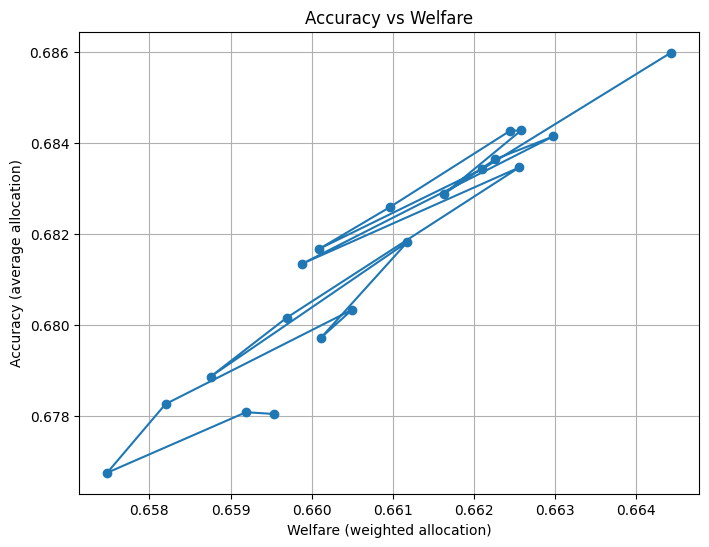

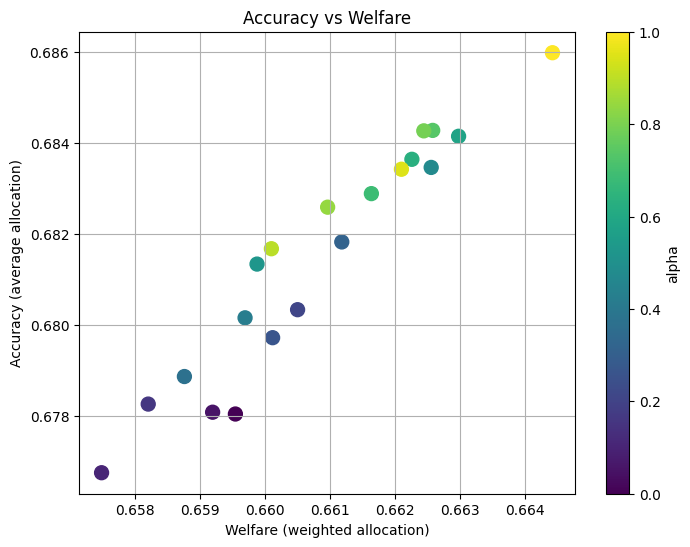

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Sort by alpha
order = np.argsort(alphas)
alphas_sorted = alphas[order]
avg_allocs_sorted = avg_allocs[order]
weighted_avg_allocs_sorted = weighted_avg_allocs[order]

# ---- Plot (line + points)
plt.figure(figsize=(8, 6))

plt.plot(
    weighted_avg_allocs_sorted[:],
    avg_allocs_sorted[:],
    marker='o',
    linestyle='-'
)

plt.xlabel('Welfare (weighted allocation)')
plt.ylabel('Accuracy (average allocation)')
plt.title('Accuracy vs Welfare')

plt.grid(True)

plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(
    weighted_avg_allocs_sorted[:],
    avg_allocs_sorted[:], c=alphas_sorted[:], cmap='viridis', s=100)

plt.colorbar(label='alpha') 

plt.xlabel('Welfare (weighted allocation)')
plt.ylabel('Accuracy (average allocation)')

plt.title('Accuracy vs Welfare')
plt.grid(True)

plt.show()
